# ME1 — EinOps / Einsum

**Task:** Build a 3-layer CNN for MNIST classification where *every* layer/operation
(convolutions, pooling, reshaping, the linear head) is implemented with
`einops` / `einsum` — **no** `torch.nn.Conv2d`, `MaxPool2d`, etc.

Train for **5 epochs** on the full 60k training split, report **test-split accuracy**,
and display a **4×4 grid of 16 sampled images** with ground-truth vs. prediction.

All heavy lifting is done through `torch.einsum` (the convolution itself) and
`einops.rearrange` (channel layout, pooling windows, flattening).

## 1. Imports & setup

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import einops
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__, "| einops:", einops.__version__)

device: cpu
torch: 2.13.0 | einops: 0.8.2


## 2. Data (MNIST)

In [2]:
transform = T.Compose([T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])

train_ds = torchvision.datasets.MNIST(".", train=True,  download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(".", train=False, download=True, transform=transform)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print("train:", len(train_ds), "| test:", len(test_ds))

train: 60000 | test: 10000


## 3. Model — 3 conv layers + linear head, all via einops/einsum

Each convolution is a direct `einsum` over the input and a learnable kernel tensor.
Pooling is a non-overlapping window reshape via `einops.rearrange` followed by a max
reduction. Each conv is *same*-sized (padding=1) so the spatial flow is
28 → 28 → 14 → 14 → 7 (two 2×2 pools), giving a final feature map of
`64 × 7 × 7`, flattened into the linear head.

```
x [B,1,28,28]
 conv1 (1→16, 3×3, pad1)  -> [B,16,28,28]  -> pool2x2 -> [B,16,14,14]
 conv2 (16→32, 3×3, pad1) -> [B,32,14,14]  -> pool2x2 -> [B,32,7,7]
 conv3 (32→64, 3×3, pad1) -> [B,64,7,7]
 flatten                   -> [B, 64*7*7]
 linear                    -> [B, 10]
```

In [3]:
class EinConv(torch.nn.Module):
    """A single convolution written with einsum + einops.

    weight: [out_c, in_c, kH, kW]
    bias:   [out_c]
    """
    def __init__(self, in_c, out_c, kernel=3, stride=1, padding=0):
        super().__init__()
        self.kernel, self.stride, self.padding = kernel, stride, padding
        # Kaiming-uniform init, matching nn.Conv2d defaults
        self.weight = torch.nn.Parameter(torch.empty(out_c, in_c, kernel, kernel))
        self.bias   = torch.nn.Parameter(torch.empty(out_c))
        nn_init(self.weight, self.bias)

    def forward(self, x):
        if self.padding:
            x = F.pad(x, [self.padding]*4)
        # Build the sliding-window stack with unfold (a view, not a conv):
        #   x: [B, C_in, H, W]  ->  win: [B, C_in, H', W', kH, kW]
        k = self.kernel
        win = x.unfold(2, k, 1).unfold(3, k, 1)
        # Convolution = contract in-channel + kernel dims against the weight.
        # Distinct labels avoid index collisions (torch 2.x einsum quirk):
        #   win: b c i j p q   weight: o c p q   ->  out: b o i j
        out = torch.einsum('bcijpq,ocpq->boij', win, self.weight)
        # bias: [o] -> broadcast over b, i, j
        out = out + self.bias[None, :, None, None]
        if self.stride > 1:
            out = einops.rearrange(out, 'b o (y sy) (x sx) -> b o y x',
                                    sy=self.stride, sx=self.stride)
        return out


def nn_init(weight, bias):
    from math import sqrt
    in_c = weight.shape[1]
    gain = sqrt(2.0 / (in_c * weight.shape[2] * weight.shape[3]))
    torch.nn.init.uniform_(weight, -gain, gain)
    fan_in = in_c * weight.shape[2] * weight.shape[3]
    bound = 1.0 / sqrt(fan_in)
    torch.nn.init.uniform_(bias, -bound, bound)


class EinPool(torch.nn.Module):
    """Non-overlapping max pooling via einops rearrange."""
    def __init__(self, factor=2):
        super().__init__()
        self.factor = factor
    def forward(self, x):
        f = self.factor
        x = einops.rearrange(x, 'b c (h f1) (w f2) -> b c h f1 w f2', f1=f, f2=f)
        return x.max(dim=-1).values.max(dim=-2).values


class EinCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = EinConv(1, 16, padding=1)
        self.pool1 = EinPool(2)
        self.conv2 = EinConv(16, 32, padding=1)
        self.pool2 = EinPool(2)
        self.conv3 = EinConv(32, 64, padding=1)
        self.flatten = einops.rearrange
        self.fc = torch.nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x)); x = self.pool1(x)
        x = F.relu(self.conv2(x)); x = self.pool2(x)
        x = F.relu(self.conv3(x))
        # flatten [B,64,7,7] -> [B, 64*7*7]
        x = einops.rearrange(x, 'b c h w -> b (c h w)')
        return self.fc(x)


model = EinCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"total params: {n_params:,}")

EinCNN(
  (conv1): EinConv()
  (pool1): EinPool()
  (conv2): EinConv()
  (pool2): EinPool()
  (conv3): EinConv()
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)
total params: 54,666


## 4. Training (5 epochs, full 60k)

In [4]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 5

def train_one_epoch(loader):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return loss_sum / total, correct / total

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(train_loader)
    print(f"Epoch {ep}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}")

Epoch 1/5  train_loss=0.1290  train_acc=0.9601


Epoch 2/5  train_loss=0.0427  train_acc=0.9865


Epoch 3/5  train_loss=0.0295  train_acc=0.9907


Epoch 4/5  train_loss=0.0219  train_acc=0.9930


Epoch 5/5  train_loss=0.0182  train_acc=0.9942


## 5. Test-split accuracy

In [5]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

test_acc = correct / total
print(f"TEST ACCURACY: {test_acc:.4f}  ({correct}/{total})")

TEST ACCURACY: 0.9911  (9911/10000)


## 6. 4×4 grid of 16 sampled images (GT vs. prediction)

We sample 16 images from the **test split** (so predictions are genuinely held-out)
and render each tile labelled `gt=<label>  pred=<label>`, colouring the frame green
when the prediction is correct and red otherwise.

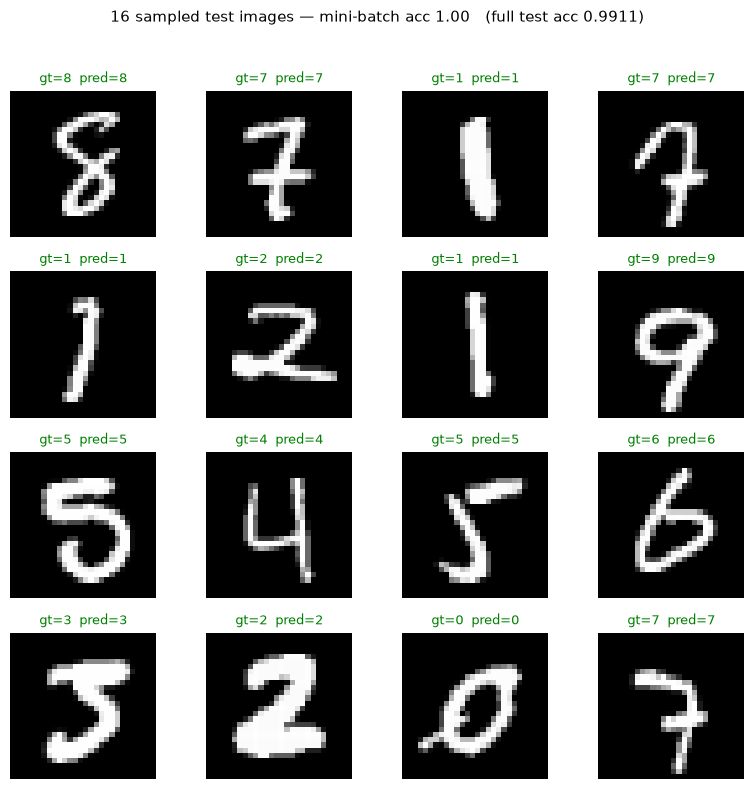

In [6]:
model.eval()
idx = np.random.choice(len(test_ds), size=16, replace=False)
imgs, gts, preds = [], [], []
with torch.no_grad():
    for i in idx:
        im, y = test_ds[i]              # [1,28,28]
        logits = model(im.unsqueeze(0).to(device))
        imgs.append(im)
        gts.append(int(y))
        preds.append(int(logits.argmax(1).item()))

imgs = torch.cat(imgs).numpy()          # [16,1,28,28] or [16,28,28]
gts  = np.array(gts); preds = np.array(preds)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, im, g, p in zip(axes.ravel(), imgs, gts, preds):
    im = im[0] if im.ndim == 3 else im   # drop channel dim if present
    ax.imshow(im, cmap='gray')
    ok = (g == p)
    ax.set_title(f"gt={g}  pred={p}", fontsize=9, color=('green' if ok else 'red'))
    for s in ax.spines.values():
        s.set_edgecolor('green' if ok else 'red')
        s.set_linewidth(2)
    ax.axis('off')
acc16 = (gts == preds).mean()
fig.suptitle(f"16 sampled test images — mini-batch acc {acc16:.2f}   (full test acc {test_acc:.4f})",
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()